<a href="https://colab.research.google.com/github/AdrianCurellCruz/World_cup_prediction_using_ML_models/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA

In [1]:
import pandas as pd
import kagglehub
import os


# Download latest version using kaggle API
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
results_file_path = os.path.join(path, "results.csv")
df_all = pd.read_csv(results_file_path)


Using Colab cache for faster access to the 'international-football-results-from-1872-to-2017' dataset.


In [2]:
print(f'Dataset dimensions {df_all.shape}')
print(f'Number of instances: {df_all.shape[0]}')
print(f'Number of variables: {df_all.shape[1]}')
print(df_all.columns.tolist())

Dataset dimensions (49477, 9)
Number of instances: 49477
Number of variables: 9
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


We check if we have NAns in the data

In [3]:
null_counts = df_all.isnull().sum()
print("Null count per column:")
print(null_counts)

Null count per column:
date           0
home_team      0
away_team      0
home_score    44
away_score    44
tournament     0
city           0
country        0
neutral        0
dtype: int64


We then extract all tournaments from the dataset and organize them into distinct hierarchical tiers. This process is essential for the subsequent development of a comprehensive Elo rating system.

In [4]:
tournaments = df_all['tournament'].unique().tolist()
print(tournaments)




['Friendly', 'British Home Championship', 'Évence Coppée Trophy', 'Muratti Vase', 'Copa Lipton', 'Copa Newton', 'Copa Premio Honor Argentino', 'Olympic Games', 'Copa Premio Honor Uruguayo', 'Far Eastern Championship Games', 'Copa Roca', 'Copa América', 'Inter-Allied Games', 'Peace Cup', 'Open International Championship', 'Soccer Ashes', 'Copa Chevallier Boutell', 'Nordic Championship', 'Central European International Cup', 'Baltic Cup', 'Balkan Cup', 'Central American and Caribbean Games', 'FIFA World Cup', 'Copa Rio Branco', 'FIFA World Cup qualification', 'Bolivarian Games', 'CCCF Championship', 'NAFC Championship', 'Copa Oswaldo Cruz', 'Asian Games', 'Pan American Championship', 'Copa del Pacífico', "Copa Bernardo O'Higgins", 'AFC Asian Cup qualification', 'Atlantic Cup', 'AFC Asian Cup', 'African Cup of Nations', 'Copa Paz del Chaco', 'Merdeka Tournament', 'UEFA Euro qualification', 'Southeast Asian Peninsular Games', 'African Friendship Games', 'UEFA Euro', 'Windward Islands Tourn

Subsequently, we categorize the tournaments into distinct tiers based on their relative importance.

#FEATURE ENGINEERING

In [5]:
# Dictionary to store the weight for each tournament
tier_weights = {}

# Iterate through each tournament and assign the weight based on its category
for tournament in tournaments:
    # TIER 1: ONLY the World Cup final stage (Weight 1.0)
    if tournament == 'FIFA World Cup':
        tier_weights[tournament] = 1.0

    # TIER 2: Top continental competitions (Weight 0.9)
    # ONLY the finals of each confederation
    elif tournament in [
        'UEFA Euro',
        'Copa América',
        'African Cup of Nations',
        'AFC Asian Cup',
        'CONCACAF Gold Cup',
        'Oceania Nations Cup'
    ]:
        tier_weights[tournament] = 0.9

    # TIER 3: Intercontinental tournaments, Olympic Games, and elite historical cups (Weight 0.8)
    elif tournament in [
        'Olympic Games',
        'Confederations Cup',
        'CONMEBOL–UEFA Cup of Champions',
        'British Home Championship',
        'Central European International Cup',
        'Balkan Cup',
        'Nordic Championship'
    ]:
        tier_weights[tournament] = 0.8

    # TIER 4: Qualifiers and UEFA Nations League (Weight 0.6)
    elif 'qualification' in tournament.lower():
        tier_weights[tournament] = 0.6

    elif tournament in ['UEFA Nations League']:
        tier_weights[tournament] = 0.6

    # TIER 5: Sub-confederation regional tournaments (Weight 0.4)
    elif tournament in [
        'AFF Championship', 'EAFF Championship', 'SAFF Cup',
        'WAFF Championship', 'COSAFA Cup', 'CECAFA Cup',
        'UNCAF Cup', 'Gulf Cup', 'Arab Cup', 'CAFA Nations Cup',
        'ASEAN Championship', 'Gold Cup qualification',
        'CONCACAF Nations League'
    ]:
        tier_weights[tournament] = 0.4

    # Also detect by prefix (e.g., all tournaments starting with AFF, SAFF, etc.)
    elif tournament.startswith(('AFF', 'EAFF', 'SAFF', 'WAFF', 'COSAFA', 'CECAFA', 'UNCAF')):
        tier_weights[tournament] = 0.4

    # TIER 6: Friendlies, invitationals, minor cups, CONIFA, multi-sport games (Weight 0.2)
    else:
        tier_weights[tournament] = 0.2

# Display the results
print("Tournament weight assignment:")
for tourney, weight in sorted(tier_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {tourney}: {weight}")

# Check how many tournaments fall into each weight category
from collections import Counter
weight_counts = Counter(tier_weights.values())
print(f"\nWeight distribution: {dict(weight_counts)}")

Tournament weight assignment:
  FIFA World Cup: 1.0
  Copa América: 0.9
  AFC Asian Cup: 0.9
  African Cup of Nations: 0.9
  UEFA Euro: 0.9
  Oceania Nations Cup: 0.9
  British Home Championship: 0.8
  Olympic Games: 0.8
  Nordic Championship: 0.8
  Central European International Cup: 0.8
  Balkan Cup: 0.8
  CONMEBOL–UEFA Cup of Champions: 0.8
  Confederations Cup: 0.8
  FIFA World Cup qualification: 0.6
  AFC Asian Cup qualification: 0.6
  UEFA Euro qualification: 0.6
  African Cup of Nations qualification: 0.6
  CONCACAF Championship qualification: 0.6
  Copa América qualification: 0.6
  CFU Caribbean Cup qualification: 0.6
  Arab Cup qualification: 0.6
  Oceania Nations Cup qualification: 0.6
  COSAFA Cup qualification: 0.6
  Gold Cup qualification: 0.6
  AFF Championship qualification: 0.6
  AFC Challenge Cup qualification: 0.6
  UEFA Nations League: 0.6
  CONCACAF Nations League qualification: 0.6
  CONIFA World Cup qualification: 0.6
  CONIFA World Football Cup qualification: 0.6

In [6]:
import pandas as pd
import math
from collections import defaultdict

def calculate_elo_ratings(df, tier_weights, base_k=20, home_advantage=60, initial_rating=1500):
    """
    Calculate Elo ratings sequentially for all matches in a DataFrame.

    Parameters:
    - df: DataFrame with columns ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']
    - tier_weights: dict mapping tournament names to weights (0.2 to 1.0)
    - base_k: Base K-factor for Elo updates
    - home_advantage: Extra Elo points added to home team
    - initial_rating: Starting Elo for all teams

    Returns:
    - df_with_elo: Original DataFrame with new columns 'elo_home_before' and 'elo_away_before'
    - elo_ratings: Final Elo ratings dictionary (useful for predicting future matches)
    """
    # Sort chronologically (oldest first) to ensure no data leakage
    df_sorted = df.sort_values('date').reset_index(drop=True)

    # Initialize Elo ratings for all teams
    elo_ratings = defaultdict(lambda: initial_rating)

    # Lists to store pre-match ratings
    home_elo_before = []
    away_elo_before = []

    # Iterate through each match chronologically
    for index, row in df_sorted.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        home_goals = row['home_score']
        away_goals = row['away_score']
        tournament = row['tournament']

        # Get current Elo ratings (BEFORE the match)
        elo_home = elo_ratings[home_team]
        elo_away = elo_ratings[away_team]

        # Store pre-match ratings for this row
        home_elo_before.append(elo_home)
        away_elo_before.append(elo_away)

        # Adjust home team Elo for home advantage
        elo_home_adj = elo_home + home_advantage

        # Calculate expected win probability (standard Elo formula)
        expected_home = 1 / (1 + 10 ** ((elo_away - elo_home_adj) / 400))
        expected_away = 1 - expected_home

        # Determine actual result (1=win, 0.5=draw, 0=loss)
        if home_goals > away_goals:
            actual_home = 1.0
            actual_away = 0.0
        elif home_goals == away_goals:
            actual_home = 0.5
            actual_away = 0.5
        else:
            actual_home = 0.0
            actual_away = 1.0

        # Margin of victory multiplier (log scale)
        goal_diff = abs(home_goals - away_goals)
        margin_multiplier = math.log(max(goal_diff, 1) + 1)

        # Tournament weight (from tier system)
        weight = tier_weights.get(tournament, 0.2)

        # Calculate K-factor for this match
        K = base_k * weight * margin_multiplier

        # Update Elo ratings (ONLY after the match)
        new_elo_home = elo_home + K * (actual_home - expected_home)
        new_elo_away = elo_away + K * (actual_away - expected_away)

        # Store updated ratings
        elo_ratings[home_team] = new_elo_home
        elo_ratings[away_team] = new_elo_away

    # Add pre-match ratings as new columns
    df_sorted['elo_home_before'] = home_elo_before
    df_sorted['elo_away_before'] = away_elo_before

    return df_sorted, dict(elo_ratings)

Now we are going to implement a new feature H2H wich is the last

In [7]:
import pandas as pd
import numpy as np
from collections import defaultdict

def calculate_weighted_h2h_features(df, half_life_days=1095):
    """
    Calculate weighted head-to-head features efficiently using a history dictionary.
    This avoids O(n^2) dataframe scans, making it much faster for large datasets.
    """
    # Sort chronologically to ensure backward-looking calculation
    df = df.sort_values('date').reset_index(drop=True)
    df['date'] = pd.to_datetime(df['date'])

    decay_constant = np.log(2) / half_life_days

    # Dictionary to store previous encounters for each team pair
    # Key: tuple(sorted([team1, team2])), Value: list of encounters
    # Each encounter is a tuple: (date, home_team, away_team, home_score, away_score)
    pair_history = defaultdict(list)

    # Initialize lists for new columns
    h2h_win_pct = []
    h2h_goal_diff = []
    h2h_match_count = []

    # Iterate chronologically
    for idx, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        current_date = row['date']
        home_goals = row['home_score']
        away_goals = row['away_score']

        # Create a consistent key for the pair (independent of home/away order)
        pair_key = tuple(sorted([home_team, away_team]))

        # Retrieve previous encounters for this specific pair (O(1) lookup)
        prev_encounters = pair_history[pair_key]

        if len(prev_encounters) == 0:
            # No historical meetings -> neutral values
            h2h_win_pct.append(0.33)
            h2h_goal_diff.append(0.0)
            h2h_match_count.append(0)
        else:
            weights = []
            goal_diffs = []
            results = []

            # Iterate through historical encounters (this list is usually very small)
            for enc_date, enc_home, enc_away, enc_home_goals, enc_away_goals in prev_encounters:
                # Map goals to the perspective of the current home_team
                if enc_home == home_team:
                    goals_for_home = enc_home_goals
                    goals_for_away = enc_away_goals
                else:  # enc_away == home_team (since they are the pair)
                    goals_for_home = enc_away_goals
                    goals_for_away = enc_home_goals

                # Time decay weight
                days_diff = (current_date - enc_date).days
                weight = np.exp(-decay_constant * max(days_diff, 0))
                weights.append(weight)

                # Goal difference from home team's perspective
                goal_diffs.append(goals_for_home - goals_for_away)

                # Result from home team's perspective (1=win, 0.5=draw, 0=loss)
                if goals_for_home > goals_for_away:
                    results.append(1.0)
                elif goals_for_home == goals_for_away:
                    results.append(0.5)
                else:
                    results.append(0.0)

            # Weighted averages
            weight_sum = sum(weights)
            if weight_sum > 0:
                weighted_win = np.average(results, weights=weights)
                weighted_goal = np.average(goal_diffs, weights=weights)
            else:
                weighted_win = 0.33
                weighted_goal = 0.0

            h2h_win_pct.append(weighted_win)
            h2h_goal_diff.append(weighted_goal)
            h2h_match_count.append(len(prev_encounters))


        pair_history[pair_key].append(
            (current_date, home_team, away_team, home_goals, away_goals)
        )

    # Add the new columns to the DataFrame
    df['h2h_win_pct'] = h2h_win_pct
    df['h2h_goal_diff'] = h2h_goal_diff
    df['h2h_match_count'] = h2h_match_count

    return df

In [8]:
def add_elo_difference(df):
    """
    Add the Elo difference feature (home_elo - away_elo) to the DataFrame.

    Parameters:
    - df: DataFrame with columns 'elo_home_before' and 'elo_away_before'

    Returns:
    - df: DataFrame with the new column 'elo_diff'
    """
    # Ensure the required columns exist
    if 'elo_home_before' not in df.columns or 'elo_away_before' not in df.columns:
        raise ValueError("DataFrame must contain 'elo_home_before' and 'elo_away_before' columns")

    df = df.copy()
    df['elo_diff'] = df['elo_home_before'] - df['elo_away_before']

    return df

After evaluating feature importance across multiple models (Random Forest and XGBoost with both 'weight' and 'gain' metrics), the home_recent_ppg and away_recent_ppg features were removed due to consistently low predictive contribution and high correlation with the more informative goal average features. This simplification reduced model complexity without sacrificing predictive performance on the 2022 World Cup validation set."

In [9]:
import pandas as pd
from collections import deque

def add_recent_form(df, window_size=5):
    """
    Add recent form features (Points Per Game over the last N matches) for both home and away teams.
    Calculated strictly using matches played BEFORE the current match date.

    Parameters:
    - df: DataFrame with columns ['date', 'home_team', 'away_team', 'home_score', 'away_score']
    - window_size: Number of previous matches to consider (default: 5)

    Returns:
    - df: DataFrame with new columns 'home_recent_ppg' and 'away_recent_ppg'
    """
    # Sort chronologically to ensure backward-looking calculation
    df_sorted = df.sort_values('date').reset_index(drop=True)

    # Dictionary to store recent history for each team
    # Each value is a deque of tuples: (points_earned, goal_diff)
    recent_history = defaultdict(lambda: deque(maxlen=window_size))

    home_recent_ppg = []
    away_recent_ppg = []

    for index, row in df_sorted.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        home_goals = row['home_score']
        away_goals = row['away_score']

        # Get recent history for both teams (ONLY past matches, nothing current)
        home_history = recent_history[home_team]
        away_history = recent_history[away_team]

        # Calculate Points Per Game (PPG) for home team
        if len(home_history) == 0:
            home_ppg = 1.5  # Neutral baseline (mid-point between 0 and 3)
        else:
            total_points = sum(points for points, _ in home_history)
            home_ppg = total_points / len(home_history)

        # Calculate PPG for away team
        if len(away_history) == 0:
            away_ppg = 1.5
        else:
            total_points = sum(points for points, _ in away_history)
            away_ppg = total_points / len(away_history)

        home_recent_ppg.append(home_ppg)
        away_recent_ppg.append(away_ppg)

        # Determine points earned in THIS match (from each team's perspective)
        if home_goals > away_goals:
            home_points = 3
            away_points = 0
        elif home_goals == away_goals:
            home_points = 1
            away_points = 1
        else:
            home_points = 0
            away_points = 3

        # Goal difference for this match (from each team's perspective)
        home_goal_diff = home_goals - away_goals
        away_goal_diff = away_goals - home_goals

        # Update history with this match's data (so it's available for FUTURE matches)
        recent_history[home_team].append((home_points, home_goal_diff))
        recent_history[away_team].append((away_points, away_goal_diff))

    # Add the new columns to the DataFrame
    df_sorted['home_recent_ppg'] = home_recent_ppg
    df_sorted['away_recent_ppg'] = away_recent_ppg

    return df_sorted

In [10]:
def add_recent_goal_average(df, window_size=5):
    """
    Add recent goal average features (average goal difference over the last N matches)
    for both home and away teams. Calculated strictly using matches played BEFORE the current match.

    Parameters:
    - df: DataFrame with columns ['date', 'home_team', 'away_team', 'home_score', 'away_score']
    - window_size: Number of previous matches to consider (default: 5)

    Returns:
    - df: DataFrame with new columns 'home_recent_goal_avg' and 'away_recent_goal_avg'
    """
    # Sort chronologically to ensure backward-looking calculation
    df_sorted = df.sort_values('date').reset_index(drop=True)

    # Dictionary to store recent goal differences for each team
    recent_goal_diffs = defaultdict(lambda: deque(maxlen=window_size))

    home_recent_goal_avg = []
    away_recent_goal_avg = []

    for index, row in df_sorted.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        home_goals = row['home_score']
        away_goals = row['away_score']

        # Get recent goal differences for both teams (ONLY past matches)
        home_diffs = recent_goal_diffs[home_team]
        away_diffs = recent_goal_diffs[away_team]

        # Calculate average goal difference for home team
        if len(home_diffs) == 0:
            home_goal_avg = 0.0  # Neutral baseline
        else:
            home_goal_avg = sum(home_diffs) / len(home_diffs)

        # Calculate average goal difference for away team
        if len(away_diffs) == 0:
            away_goal_avg = 0.0
        else:
            away_goal_avg = sum(away_diffs) / len(away_diffs)

        home_recent_goal_avg.append(home_goal_avg)
        away_recent_goal_avg.append(away_goal_avg)

        # Goal difference from each team's perspective
        home_goal_diff = home_goals - away_goals
        away_goal_diff = away_goals - home_goals

        # Update history with this match's data (for future matches)
        recent_goal_diffs[home_team].append(home_goal_diff)
        recent_goal_diffs[away_team].append(away_goal_diff)

    # Add the new columns to the DataFrame
    df_sorted['home_recent_goal_avg'] = home_recent_goal_avg
    df_sorted['away_recent_goal_avg'] = away_recent_goal_avg

    return df_sorted

In [11]:
def add_target_variable(df):
    """
    Add the target variable (match result from the home team's perspective).

    Encoding:
    - 0: Draw
    - 1: Home Win
    - 2: Away Win

    Parameters:
    - df: DataFrame with columns 'home_score' and 'away_score'

    Returns:
    - df: DataFrame with new column 'target'
    """
    df = df.copy()

    def get_result(row):
        if row['home_score'] > row['away_score']:
            return 1  # Home Win
        elif row['home_score'] == row['away_score']:
            return 0  # Draw
        else:
            return 2  # Away Win

    df['target'] = df.apply(get_result, axis=1)

    return df

In [12]:
import pandas as pd
import math
from collections import defaultdict


# Calculate Elo ratings (uses only past data)
df_full_with_elo, final_elo_ratings = calculate_elo_ratings(
    df=df_all,
    tier_weights=tier_weights,
    base_k=20,
    home_advantage=60
)

# Add Elo Difference feature
df_full_features = add_elo_difference(df_full_with_elo)


# Add Recent Goal Average over last 5 matches
df_full_features = add_recent_goal_average(df_full_features, window_size=5)
df_full_features=calculate_weighted_h2h_features(df_full_features,1095)
# Add the Target variable (0=Draw, 1=Home Win, 2=Away Win)
df_full_features = add_target_variable(df_full_features)

# Split chronologically to avoid data leakage
cutoff_date = '2022-11-20'
df_train = df_full_features[df_full_features['date'] < cutoff_date]
df_test = df_full_features[
    (df_full_features['tournament'] == 'FIFA World Cup') &
    (df_full_features['date'].dt.year == 2022)
]


# Prepare features and target for the model
feature_cols = [
    'elo_diff',
    'elo_home_before',
    'elo_away_before',
    'home_recent_goal_avg',
    'away_recent_goal_avg',
    'h2h_win_pct',
    'h2h_goal_diff',
    'h2h_match_count'
]

X_train = df_train[feature_cols].fillna(0)
y_train = df_train['target']

X_test = df_test[feature_cols].fillna(0)
y_test = df_test['target']

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
# Sanity check: Verify that all test matches are between Nov 20 - Dec 18, 2022
print(f"\nTest date range: {df_test['date'].min()} to {df_test['date'].max()}")
print(f"Unique tournaments in test set: {df_test['tournament'].unique()}")



Train shape: (45700, 8), Test shape: (64, 8)

Test date range: 2022-11-20 00:00:00 to 2022-12-18 00:00:00
Unique tournaments in test set: ['FIFA World Cup']


#MODELING

##RANDOM FOREST

###Baseline

In [13]:
# Train and evaluate the model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy on 2022 World Cup: {accuracy * 100:.2f}%")



Accuracy on 2022 World Cup: 54.69%


In [24]:
from sklearn.model_selection import cross_val_score

# Calcula el CV del baseline (con los mismos folds que usó Optuna)
baseline_rf = RandomForestClassifier(random_state=42)
cv_scores_baseline = cross_val_score(baseline_rf, X_train, y_train, cv=tscv, scoring='accuracy')
print(f"Baseline CV accuracy: {cv_scores_baseline.mean():.4f} (+/- {cv_scores_baseline.std():.4f})")

Baseline CV accuracy: 0.5450 (+/- 0.0115)


Top 10 Most Important Features (Random Forest):
                Feature  Importance
0              elo_diff    0.302584
6         h2h_goal_diff    0.152992
2       elo_away_before    0.129385
5           h2h_win_pct    0.111275
1       elo_home_before    0.111049
3  home_recent_goal_avg    0.078369
4  away_recent_goal_avg    0.073845
7       h2h_match_count    0.040503


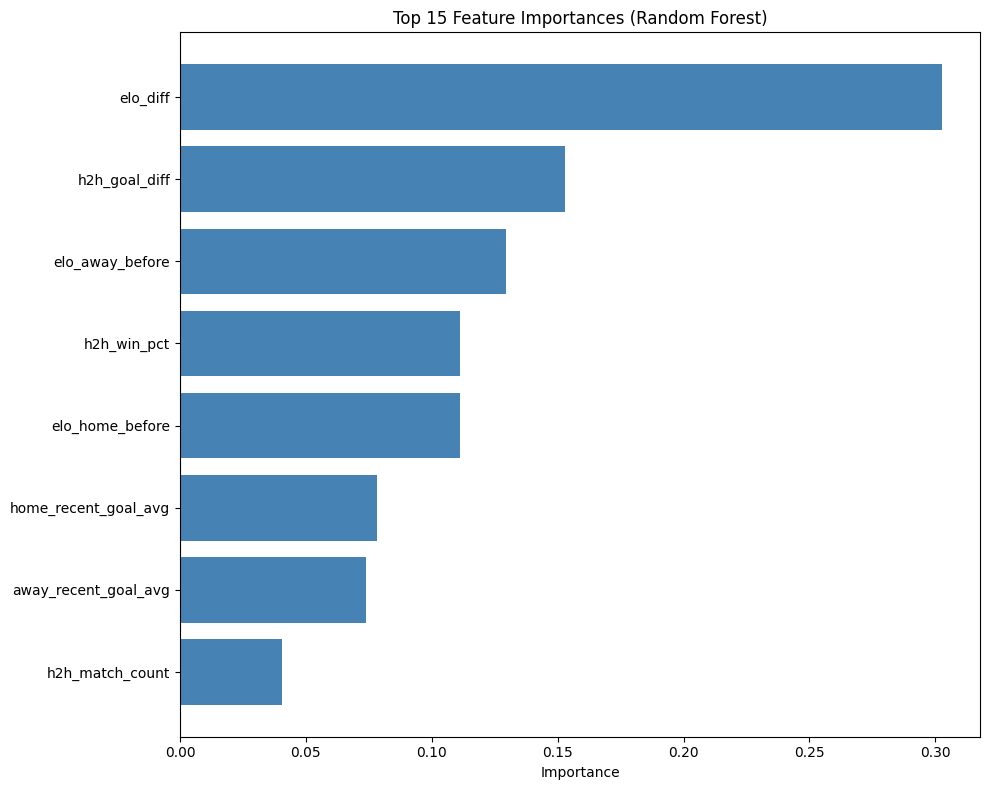


Cumulative importance of top features:
                Feature  Importance  Cumulative
0              elo_diff    0.302584    0.302584
6         h2h_goal_diff    0.152992    0.455576
2       elo_away_before    0.129385    0.584960
5           h2h_win_pct    0.111275    0.696235
1       elo_home_before    0.111049    0.807284
3  home_recent_goal_avg    0.078369    0.885653
4  away_recent_goal_avg    0.073845    0.959497
7       h2h_match_count    0.040503    1.000000


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get feature importances from the trained model
feature_importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features (Random Forest):")
print(importance_df.head(10))

# Visualize the top 15 features
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Cumulative importance
importance_df['Cumulative'] = importance_df['Importance'].cumsum()
print("\nCumulative importance of top features:")
print(importance_df.head(10)[['Feature', 'Importance', 'Cumulative']])

###HPO

In [22]:
!pip install optuna
!pip install optuna optuna-integration[sklearn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 5.0 MB/s eta 0:00:00


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, CategoricalDistribution
import numpy as np
import time



# Define the hyperparameter search space
# We use Optuna's distribution objects for better sampling
param_distributions = {
    'n_estimators': IntDistribution(50, 300),
    'max_depth': IntDistribution(3, 20),
    'min_samples_split': IntDistribution(2, 10),
    'min_samples_leaf': IntDistribution(1, 10),
    'criterion': CategoricalDistribution(['gini', 'entropy'])  # Split quality metric
}

# TimeSeriesSplit to respect chronological order within the training set
# This prevents using future matches to validate past matches during cross-validation
# n_splits=5 means 5 folds, train uses 80% of the time-series, test uses 20% (chronologically)
tscv = TimeSeriesSplit(n_splits=5)

# Instantiate the base model
base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Configure OptunaSearchCV
rf_optuna = OptunaSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions,
    n_trials=30,
    scoring='accuracy',
    cv=tscv,
    n_jobs=1,
    verbose=1,
    random_state=42
)


print("Starting Optuna hyperparameter optimization (30 trials)...")
start_time = time.time()

# Fit on the TRAINING set (matches BEFORE the 2022 World Cup)
rf_optuna.fit(X_train, y_train)

end_time = time.time()
duration = end_time - start_time


print("\n" + "-" * 50)
print(f"Best hyperparameters found: {rf_optuna.best_params_}")
print(f"Best cross-validation accuracy (TimeSeriesSplit): {rf_optuna.best_score_:.4f}")
print(f"Total execution time: {duration:.2f} seconds")
print("-" * 50)


best_rf_model = rf_optuna.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\nAccuracy of Tuned Random Forest on 2022 World Cup: {accuracy_tuned * 100:.2f}%")



/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.sklearn` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.sklearn` instead.
  return _bootstrap._gcd_import(name[level:], package, level)
/tmp/ipykernel_19883/2125298892.py:31: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  rf_optuna = OptunaSearchCV(
[I 2026-06-24 14:09:50,431] A new study created in memory with name: no-name-c963944a-0c84-47cf-9c47-a8b365c554b1
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 45700 samples...


Starting Optuna hyperparameter optimization (30 trials)...


/usr/local/lib/python3.12/dist-packages/optuna_integration/sklearn/sklearn.py:275: FutureWarning: `optuna.terminator` module has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  report_cross_validation_scores(trial, scores_list)
[I 2026-06-24 14:10:50,052] Trial 0 finished with value: 0.5593487394957983 and parameters: {'n_estimators': 164, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with value: 0.5593487394957983.
/usr/local/lib/python3.12/dist-packages/optuna_integration/sklearn/sklearn.py:275: FutureWarning: `optuna.terminator` module has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  report_cross_validation_scores(trial, scores_list)
[I 2026-06-24 14:11:13,233] Trial 1 finished with value: 0.5629989495798319 and parameters: {'n_estimators': 103, 'max_depth': 6, 'min_sam


--------------------------------------------------
Best hyperparameters found: {'n_estimators': 83, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 9, 'criterion': 'entropy'}
Best cross-validation accuracy (TimeSeriesSplit): 0.5648
Total execution time: 950.50 seconds
--------------------------------------------------

Accuracy of Tuned Random Forest on 2022 World Cup: 53.12%


Hyperparameter tuning using Optuna with TimeSeriesSplit improved the cross-validation accuracy from ~54% (baseline) to 56.48%, demonstrating a robust enhancement in predictive performance. When evaluated on the 2022 World Cup (a small test set of 64 matches), the tuned model scored 53.12% versus the baseline's 54%, a negligible difference attributable to the high variance of the small sample.

##XGB BOOSTING

###Baseline

In [15]:
from xgboost import XGBClassifier

# Baseline XGBoost
xgb_baseline = XGBClassifier(random_state=42)
xgb_baseline.fit(X_train, y_train)
y_pred_xgb = xgb_baseline.predict(X_test)
accuracy_baseline=accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Baseline Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")

XGBoost Baseline Accuracy: 50.00%


Top 10 Most Important Features (XGBoost, importance_type='gain'):
                Feature  Importance
0              elo_diff   10.592790
1         h2h_goal_diff    2.987659
2  away_recent_goal_avg    2.293706
3  home_recent_goal_avg    2.238941
4       elo_away_before    2.126550
5           h2h_win_pct    1.989297
6       h2h_match_count    1.874278
7       elo_home_before    1.798720


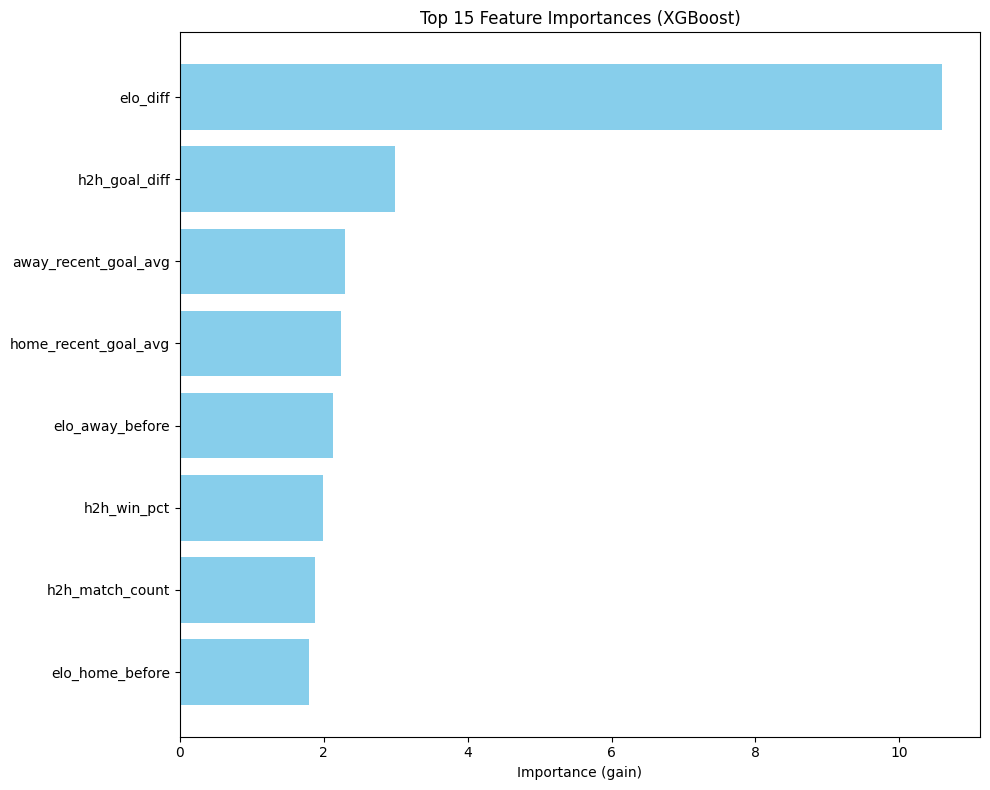


Cumulative importance of top features:
                Feature  Importance  Cumulative
0              elo_diff   10.592790   10.592790
1         h2h_goal_diff    2.987659   13.580448
2  away_recent_goal_avg    2.293706   15.874155
3  home_recent_goal_avg    2.238941   18.113096
4       elo_away_before    2.126550   20.239646
5           h2h_win_pct    1.989297   22.228943
6       h2h_match_count    1.874278   24.103221
7       elo_home_before    1.798720   25.901940


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


importance_type = 'gain'

# Get feature importance from the booster object
importance_dict = xgb_baseline.get_booster().get_score(importance_type=importance_type)

# Convert to DataFrame
importance_df_xgb = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
}).sort_values('Importance', ascending=False)

# If some features have zero importance, they won't appear in the dict.
# We need to add them manually to keep consistency.
all_features = X_train.columns
for feat in all_features:
    if feat not in importance_df_xgb['Feature'].values:
        importance_df_xgb = pd.concat([importance_df_xgb, pd.DataFrame({'Feature': [feat], 'Importance': [0]})], ignore_index=True)

# Sort again
importance_df_xgb = importance_df_xgb.sort_values('Importance', ascending=False).reset_index(drop=True)

print(f"Top 10 Most Important Features (XGBoost, importance_type='{importance_type}'):")
print(importance_df_xgb.head(10))


top_n = 15
top_features_xgb = importance_df_xgb.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features_xgb['Feature'], top_features_xgb['Importance'], color='skyblue')
plt.xlabel(f'Importance ({importance_type})')
plt.title(f'Top {top_n} Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


importance_df_xgb['Cumulative'] = importance_df_xgb['Importance'].cumsum()
print("\nCumulative importance of top features:")
print(importance_df_xgb.head(10)[['Feature', 'Importance', 'Cumulative']])

###HPO

In [40]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, FloatDistribution, CategoricalDistribution
from sklearn.metrics import accuracy_score
import numpy as np
import time



# Define the hyperparameter search space for XGBoost
param_distributions = {
    'n_estimators': IntDistribution(100, 250),
    'max_depth': IntDistribution(2, 10),
    'learning_rate': FloatDistribution(0.01, 0.3),
    'subsample': FloatDistribution(0.6, 1.0),
    'colsample_bytree': FloatDistribution(0.6, 1.0),
    'reg_alpha': FloatDistribution(0, 1.0),
    'reg_lambda': FloatDistribution(0, 1.0),
    'min_child_weight': IntDistribution(1, 10)
}

# TimeSeriesSplit to respect chronological order within the training set
# n_splits=5 means 5 folds, train uses 80% of the time-series, test uses 20% (chronologically)
tscv = TimeSeriesSplit(n_splits=5)

# Instantiate the base XGBoost model
# eval_metric='mlogloss' is required for multiclass classification
# verbosity=0 silences training logs
# n_jobs=-1 uses all CPU cores
base_xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1
)

# Configure OptunaSearchCV
xgb_optuna = OptunaSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_trials=30,                     # Number of hyperparameter combinations to try
    scoring='accuracy',              # Metric to optimize
    cv=tscv,                         # Time Series Cross Validation
    n_jobs=.1,                        # Keep at 1 to avoid memory issues in Colab
    verbose=1,                       # Show progress
    random_state=42
)


print("Starting Optuna hyperparameter optimization for XGBoost (30 trials)...")
start_time = time.time()

# Fit on the TRAINING set (matches BEFORE the 2022 World Cup)
xgb_optuna.fit(X_train, y_train)

end_time = time.time()
duration = end_time - start_time


# RESULTS

print("\n" + "-" * 50)
print(f"Best hyperparameters found: {xgb_optuna.best_params_}")
print(f"Best cross-validation accuracy (TimeSeriesSplit): {xgb_optuna.best_score_:.4f}")
print(f"Total execution time: {duration:.2f} seconds")
print("-" * 50)


# EVALUATE THE TUNED MODEL ON THE 2022 WORLD CUP

best_xgb_model = xgb_optuna.best_estimator_
y_pred_tuned_xgb = best_xgb_model.predict(X_test)
accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)

print(f"\nAccuracy of Tuned XGBoost on 2022 World Cup: {accuracy_tuned_xgb * 100:.2f}%")

/tmp/ipykernel_19883/3716477139.py:39: ExperimentalWarning:

OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.

[I 2026-06-24 15:15:04,537] A new study created in memory with name: no-name-9c2c1f0d-2d87-4b64-a27d-d719a9e7347f
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 45700 samples...


Starting Optuna hyperparameter optimization for XGBoost (30 trials)...


KeyboardInterrupt: 

/tmp/ipykernel_19883/130802101.py:3: ExperimentalWarning:

optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.



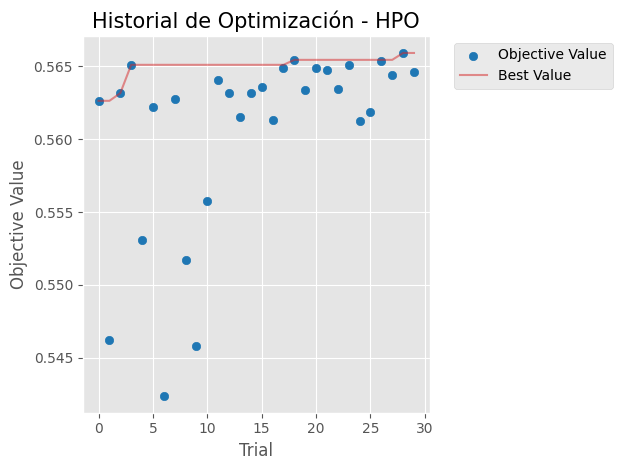

In [36]:
from optuna.visualization.matplotlib import plot_optimization_history
study = xgb_optuna.study_
plot_optimization_history(study)
plt.title("Historial de Optimización - HPO", fontsize=15)
plt.show()

/tmp/ipykernel_19883/699106045.py:3: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



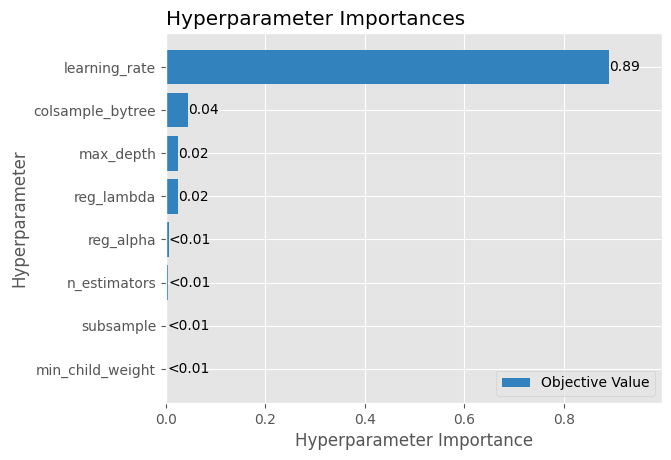

In [37]:
from optuna.visualization.matplotlib import plot_param_importances
study = xgb_optuna.study_
plot_param_importances(study)
plt.show()

##CAT BOOSTING


In [17]:
!pip3 install catboost

###Baseline

In [18]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform



# Instanciate baseline model with default settings
baseline_model = CatBoostClassifier(verbose=0, random_seed=42)

# Train on historical data (pre-2022)
baseline_model.fit(X_train, y_train)

# Predict on 2022 World Cup
y_pred_baseline = baseline_model.predict(X_test)
y_pred_proba_baseline = baseline_model.predict_proba(X_test)

# Metrics
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy (2022 World Cup): {accuracy_baseline * 100:.2f}%")
print("\nConfusion Matrix (Baseline):")
print(confusion_matrix(y_test, y_pred_baseline))
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline, target_names=['Draw', 'Home Win', 'Away Win']))

Baseline Accuracy (2022 World Cup): 53.12%

Confusion Matrix (Baseline):
[[ 1  9  5]
 [ 0 21  7]
 [ 0  9 12]]

Classification Report (Baseline):
              precision    recall  f1-score   support

        Draw       1.00      0.07      0.12        15
    Home Win       0.54      0.75      0.63        28
    Away Win       0.50      0.57      0.53        21

    accuracy                           0.53        64
   macro avg       0.68      0.46      0.43        64
weighted avg       0.63      0.53      0.48        64



##HISTORY GRADIENT BOOSTING

###Baseline

In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# HISTGRADIENTBOOSTING BASELINE (Default parameters)
print("TRAINING HISTGRADIENTBOOSTING BASELINE (Default parameters)")

# Instantiate the model with default parameters
# random_state=42 ensures reproducibility
# default parameters: max_iter=100, max_depth=None, learning_rate=0.1
hgb_model = HistGradientBoostingClassifier(random_state=42)

# Train on historical data (pre-2022)
hgb_model.fit(X_train, y_train)

# Predict on 2022 World Cup
y_pred_hgb = hgb_model.predict(X_test)
y_pred_proba_hgb = hgb_model.predict_proba(X_test)

# Calculate metrics
accuracy_hgb = accuracy_score(y_test, y_pred_hgb)

print(f"Baseline Accuracy (2022 World Cup): {accuracy_hgb * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_hgb, target_names=['Draw', 'Home Win', 'Away Win']))




TRAINING HISTGRADIENTBOOSTING BASELINE (Default parameters)
Baseline Accuracy (2022 World Cup): 48.44%

Confusion Matrix:
[[ 0 10  5]
 [ 0 22  6]
 [ 0 12  9]]

Classification Report:
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00        15
    Home Win       0.50      0.79      0.61        28
    Away Win       0.45      0.43      0.44        21

    accuracy                           0.48        64
   macro avg       0.32      0.40      0.35        64
weighted avg       0.37      0.48      0.41        64



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Top 10 Most Important Features (Random Forest):
                Feature  Importance
0              elo_diff    0.302584
6         h2h_goal_diff    0.152992
2       elo_away_before    0.129385
5           h2h_win_pct    0.111275
1       elo_home_before    0.111049
3  home_recent_goal_avg    0.078369
4  away_recent_goal_avg    0.073845
7       h2h_match_count    0.040503


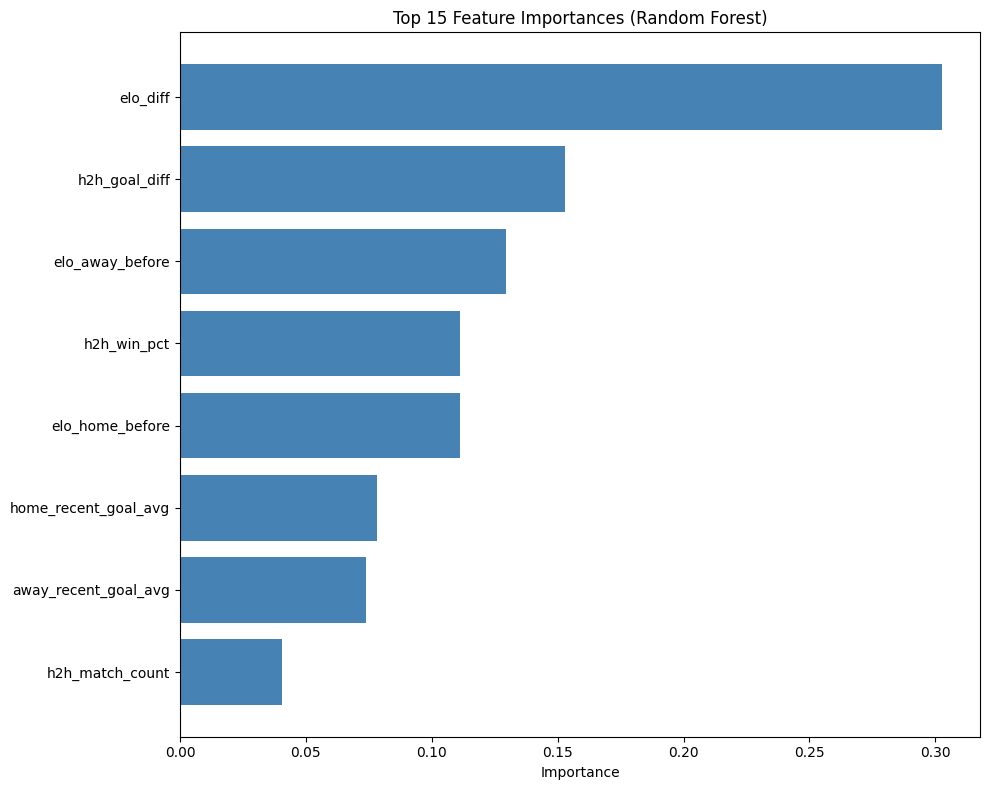


Cumulative importance of top features:
                Feature  Importance  Cumulative
0              elo_diff    0.302584    0.302584
6         h2h_goal_diff    0.152992    0.455576
2       elo_away_before    0.129385    0.584960
5           h2h_win_pct    0.111275    0.696235
1       elo_home_before    0.111049    0.807284
3  home_recent_goal_avg    0.078369    0.885653
4  away_recent_goal_avg    0.073845    0.959497
7       h2h_match_count    0.040503    1.000000


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get feature importances from the trained model
feature_importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features (Random Forest):")
print(importance_df.head(10))

# Visualize the top 15 features
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Cumulative importance
importance_df['Cumulative'] = importance_df['Importance'].cumsum()
print("\nCumulative importance of top features:")
print(importance_df.head(10)[['Feature', 'Importance', 'Cumulative']])